In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allantools 

In [2]:
N = 1000 # Num of points
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

In [3]:
# Generate white noise
freq_white = allantools.noise.white(N)
freq_pink = allantools.noise.pink(N)
freq_rw = allantools.noise.brown(N)

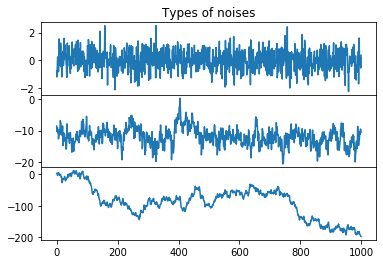

In [4]:
f, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
ax1.set_title('Types of noises')
ax1.plot(freq_white)
ax2.plot(freq_pink)
ax3.plot(freq_rw)
f.subplots_adjust(hspace=0)
plt.setp([a.get_xticklabels() for a in f.axes[:-1]], visible=False)

In [7]:
def allanmdev(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for jj in range(len(m)): 
        print('current jj = ' + str(jj))
        # Sliding windows 
        left = 0 
        right = m[jj]
        ybar = []

        while right <= N:
            ybar.append(np.mean(y[left:right]))
            left += step 
            right += step 

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate modified allan var 
        outersum = []
        j = 0 
        while j < M-3*m[jj]+2:
            i = j
            middlesum = []
            while i <= j+m[jj]-1:
                k = i
                innersum = []
                while k <= i+m[jj]-1:
                    innersum.append(ybar[k+m[jj]]-ybar[k])
                    k += step
                middlesum.append(np.sum(innersum))
                i += step
            outersum.append(np.sum(middlesum)**2)
            j += step 

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/((M-3*m[jj]+2)*2*m[jj]**4))
        
        # Calculate tau
        tau.append(tau0*m[jj])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [8]:
tau_white, allanstd_white = allanmdev(freq_white,t,1)

current jj = 0
current jj = 1
current jj = 2
current jj = 3
current jj = 4
current jj = 5
current jj = 6
current jj = 7
current jj = 8
current jj = 9
current jj = 10
current jj = 11
current jj = 12
current jj = 13
current jj = 14
current jj = 15
current jj = 16
current jj = 17
current jj = 18
current jj = 19
current jj = 20
current jj = 21
current jj = 22
current jj = 23
current jj = 24
current jj = 25
current jj = 26
current jj = 27
current jj = 28
current jj = 29
current jj = 30
current jj = 31
current jj = 32
current jj = 33
current jj = 34
current jj = 35
current jj = 36
current jj = 37
current jj = 38
current jj = 39
current jj = 40
current jj = 41
current jj = 42
current jj = 43
current jj = 44
current jj = 45
current jj = 46
current jj = 47
current jj = 48
current jj = 49
current jj = 50
current jj = 51
current jj = 52
current jj = 53
current jj = 54
current jj = 55
current jj = 56
current jj = 57
current jj = 58
current jj = 59
current jj = 60
current jj = 61
current jj = 62
cu

In [9]:
allanstd_white

array([ 0.24615257,  0.21509389,  0.19292085,  0.17440331,  0.15862425,
        0.1458684 ,  0.13602941,  0.12820518,  0.12182165,  0.11662264,
        0.11234563,  0.10854332,  0.10491521,  0.10136435,  0.09791287,
        0.09459961,  0.09143614,  0.08841233,  0.08550323,  0.0826805 ,
        0.07993403,  0.07728845,  0.07478282,  0.07245092,  0.07031394,
        0.06837606,  0.0666297 ,  0.06506311,  0.06365447,  0.06237595,
        0.06120351,  0.06012264,  0.0591291 ,  0.058226  ,  0.0574134 ,
        0.05669023,  0.05605266,  0.05549624,  0.05501568,  0.05460592,
        0.05426036,  0.05397035,  0.05372653,  0.05352023,  0.05334362,
        0.05319009,  0.05305433,  0.05293106,  0.05281604,  0.05270538,
        0.05259521,  0.05248186,  0.05236174,  0.052231  ,  0.05208547,
        0.05192142,  0.05173558,  0.05152578,  0.05129023,  0.0510284 ,
        0.05074114,  0.05042944,  0.05009516,  0.0497401 ,  0.04936434,
        0.04896802,  0.04855245,  0.04811907,  0.04766896,  0.04

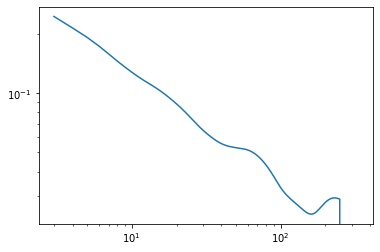

In [18]:
plt.loglog(tau_white,allanstd_white)

In [19]:
def allanmdev_ref(freq):
    (taus, adevs, errors, ns) = allantools.mdev(freq, data_type='freq', taus = t)
    return taus, adevs, errors, ns

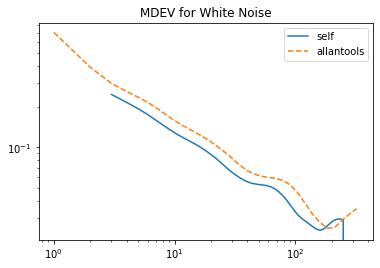

In [20]:
plt.loglog(tau_white,allanstd_white, label = 'self')
plt.loglog(allanmdev_ref(freq_white)[0],allanmdev_ref(freq_white)[1], label='allantools', linestyle='dashed')
plt.title('MDEV for White Noise')
plt.legend()

In [21]:
tau_pink, allanstd_pink = allanmdev(freq_pink,t,1)

current jj = 0
current jj = 1
current jj = 2
current jj = 3
current jj = 4
current jj = 5
current jj = 6
current jj = 7
current jj = 8
current jj = 9
current jj = 10
current jj = 11
current jj = 12
current jj = 13
current jj = 14
current jj = 15
current jj = 16
current jj = 17
current jj = 18
current jj = 19
current jj = 20
current jj = 21
current jj = 22
current jj = 23
current jj = 24
current jj = 25
current jj = 26
current jj = 27
current jj = 28
current jj = 29
current jj = 30
current jj = 31
current jj = 32
current jj = 33
current jj = 34
current jj = 35
current jj = 36
current jj = 37
current jj = 38
current jj = 39
current jj = 40
current jj = 41
current jj = 42
current jj = 43
current jj = 44
current jj = 45
current jj = 46
current jj = 47
current jj = 48
current jj = 49
current jj = 50
current jj = 51
current jj = 52
current jj = 53
current jj = 54
current jj = 55
current jj = 56
current jj = 57
current jj = 58
current jj = 59
current jj = 60
current jj = 61
current jj = 62
cu

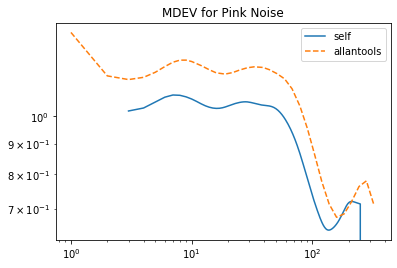

In [23]:
plt.loglog(tau_pink,allanstd_pink, label = 'self')
plt.loglog(allanmdev_ref(freq_pink)[0],allanmdev_ref(freq_pink)[1], label='allantools', linestyle='dashed')
plt.title('MDEV for Pink Noise')
plt.legend()

In [26]:
def allanmdev_alt(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for jj in range(len(m)): 
        print('current jj = ' + str(jj))

        # M is the number of times we can move the averaging window from the beginning to the end
        M = N-m[jj]+1

        # Calculate modified allan var 
        outersum = []
        j_range = np.arange(0, M - 3 * m[jj] + 2, step)
        while j < M-3*m[jj]+2:
            i = j
            middlesum = []
            while i <= j+m[jj]-1:
                k = i
                innersum = []
                while k <= i+m[jj]-1:
                    innersum.append(y[k+m[jj]]-y[k])
                    k += step
                middlesum.append(np.sum(innersum))
                i += step
            outersum.append(np.sum(middlesum)**2)
            j += step 

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/((M-3*m[jj]+2)*2*m[jj]**4))
        
        # Calculate tau
        tau.append(tau0*m[jj])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [27]:
tau_white_alt, allanstd_white_alt = allanmdev_alt(freq_white,t,1)

current jj = 0
current jj = 1
current jj = 2
current jj = 3
current jj = 4
current jj = 5
current jj = 6
current jj = 7
current jj = 8
current jj = 9
current jj = 10
current jj = 11
current jj = 12
current jj = 13
current jj = 14
current jj = 15
current jj = 16
current jj = 17
current jj = 18
current jj = 19
current jj = 20
current jj = 21
current jj = 22
current jj = 23
current jj = 24
current jj = 25
current jj = 26
current jj = 27
current jj = 28
current jj = 29
current jj = 30
current jj = 31
current jj = 32
current jj = 33
current jj = 34
current jj = 35
current jj = 36
current jj = 37
current jj = 38
current jj = 39
current jj = 40
current jj = 41
current jj = 42
current jj = 43
current jj = 44
current jj = 45
current jj = 46
current jj = 47
current jj = 48
current jj = 49
current jj = 50
current jj = 51
current jj = 52
current jj = 53
current jj = 54
current jj = 55
current jj = 56
current jj = 57
current jj = 58
current jj = 59
current jj = 60
current jj = 61
current jj = 62
cu

KeyboardInterrupt: 